In [1]:
# Phase 4 — Churn Prediction Model
# Importing all the libraries we'll need for this entire notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import pickle

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# Loading our master customer table that we built in Phase 2
# This is the single source of truth for our entire ML model

df = pd.read_csv(r'C:\Users\vedik\OneDrive\Desktop\Olist Churn Project\outputs\master_customer_table.csv')

print("Shape:", df.shape)
print("\nFirst look at the data:")
df.head()

Shape: (93350, 13)

First look at the data:


,customer_unique_id,total_orders,total_spend,avg_spend_per_order,avg_review_score,avg_delivery_delay,first_purchase_date,last_purchase_date,customer_state,fav_category,days_since_last_purchase,customer_lifespan_days,churned
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,129.90,5.0,-5.0,2018-05-10 10:56:27,2018-05-10 10:56:27,SP,cama_mesa_banho,111,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,18.90,4.0,-5.0,2018-05-07 11:11:27,2018-05-07 11:11:27,SP,beleza_saude,114,0,0
2,0000f46a3911fa3c0805444483337064,1,69.00,69.00,3.0,-2.0,2017-03-10 21:05:03,2017-03-10 21:05:03,SC,papelaria,536,0,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,25.99,4.0,-12.0,2017-10-12 20:29:41,2017-10-12 20:29:41,PA,telefonia,320,0,1
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,180.00,5.0,-8.0,2017-11-14 19:45:42,2017-11-14 19:45:42,SP,telefonia,287,0,1


In [3]:
# Before building any model, we need to understand what we're working with
# Check for missing values and data types

print("Column names and data types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

Column names and data types:
customer_unique_id              str
total_orders                  int64
total_spend                 float64
avg_spend_per_order         float64
avg_review_score            float64
avg_delivery_delay          float64
first_purchase_date             str
last_purchase_date              str
customer_state                  str
fav_category                    str
days_since_last_purchase      int64
customer_lifespan_days        int64
churned                       int64
dtype: object

Missing values per column:
customer_unique_id            0
total_orders                  0
total_spend                   0
avg_spend_per_order           0
avg_review_score            603
avg_delivery_delay            0
first_purchase_date           0
last_purchase_date            0
customer_state                0
fav_category                  0
days_since_last_purchase      0
customer_lifespan_days        0
churned                       0
dtype: int64


In [4]:
# Step 1: Fill the 603 missing review scores with the median
# Median is safer than mean — it's not affected by extreme values
df['avg_review_score'] = df['avg_review_score'].fillna(df['avg_review_score'].median())

# Step 2: Select only the columns useful for the model
# We drop: ID, date strings (info already captured in other columns), and the target variable
features = ['total_orders', 'total_spend', 'avg_spend_per_order',
            'avg_review_score', 'avg_delivery_delay', 'days_since_last_purchase',
            'customer_lifespan_days', 'customer_state', 'fav_category']

target = 'churned'

print("Missing values in review score after fix:", df['avg_review_score'].isnull().sum())
print("\nFeatures selected:", len(features))
print(features)

Missing values in review score after fix: 0

Features selected: 9
['total_orders', 'total_spend', 'avg_spend_per_order', 'avg_review_score', 'avg_delivery_delay', 'days_since_last_purchase', 'customer_lifespan_days', 'customer_state', 'fav_category']


In [5]:
# LabelEncoder converts each unique text value into a unique integer
# Example: "SP" → 24, "RJ" → 19, "MG" → 11 (arbitrary but consistent)

le_state = LabelEncoder()
le_category = LabelEncoder()

df['customer_state_encoded'] = le_state.fit_transform(df['customer_state'])
df['fav_category_encoded'] = le_category.fit_transform(df['fav_category'])

# Verify the encoding worked
print("Sample state encoding:")
print(df[['customer_state', 'customer_state_encoded']].drop_duplicates().sort_values('customer_state').head(8))

print("\nSample category encoding:")
print(df[['fav_category', 'fav_category_encoded']].drop_duplicates().sort_values('fav_category').head(8))

Sample state encoding:
    customer_state  customer_state_encoded
145             AC                       0
105             AL                       1
394             AM                       2
902             AP                       3
33              BA                       4
93              CE                       5
26              DF                       6
10              ES                       7

Sample category encoding:
                   fav_category  fav_category_encoded
619   agro_industria_e_comercio                     0
381                   alimentos                     1
365           alimentos_bebidas                     2
339                       artes                     3
5702         artes_e_artesanato                     4
4126          artigos_de_festas                     5
81             artigos_de_natal                     6
417                       audio                     7


In [6]:
# Build the final list of features — replacing text columns with their encoded versions
final_features = ['total_orders', 'total_spend', 'avg_spend_per_order',
                  'avg_review_score', 'avg_delivery_delay', 'days_since_last_purchase',
                  'customer_lifespan_days', 'customer_state_encoded', 'fav_category_encoded']

# X = the input features (what the model learns FROM)
# y = the target (what the model is trying to PREDICT)
X = df[final_features]
y = df[target]

# Split: 80% for training, 20% for testing
# random_state=42 just means the split is reproducible — same split every time you run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Total customers:", len(X))
print("\nTraining set size:", len(X_train))
print("Testing set size: ", len(X_test))
print("\nChurn rate in training set:", round(y_train.mean() * 100, 1), "%")
print("Churn rate in testing set: ", round(y_test.mean(), 2) * 100, "%")

Total customers: 93350

Training set size: 74680
Testing set size:  18670

Churn rate in training set: 59.0 %
Churn rate in testing set:  57.99999999999999 %


In [8]:
# Logistic Regression — the "hello world" of classification models
# Removing leaky features — these columns directly encode the churn definition
# A real model must predict churn from BEHAVIOURAL signals only

clean_features = ['total_orders', 'total_spend', 'avg_spend_per_order',
                  'avg_review_score', 'avg_delivery_delay',
                  'customer_state_encoded', 'fav_category_encoded']

X = df[clean_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Retrain Logistic Regression on clean features
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

print("Logistic Regression (clean) trained successfully!")
print("\nClassification Report:")
print(classification_report(y_test, lr_predictions, target_names=['Not Churned', 'Churned']))

Logistic Regression (clean) trained successfully!

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.41      0.00      0.00      7760
     Churned       0.58      1.00      0.74     10910

    accuracy                           0.58     18670
   macro avg       0.50      0.50      0.37     18670
weighted avg       0.51      0.58      0.43     18670



In [9]:
# Random Forest builds hundreds of decision trees and combines their votes
# n_estimators=100 means 100 trees
# n_jobs=-1 uses all your CPU cores to train faster

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print("Random Forest trained successfully!")
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions, target_names=['Not Churned', 'Churned']))

Random Forest trained successfully!

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.60      0.48      0.53      7760
     Churned       0.68      0.77      0.72     10910

    accuracy                           0.65     18670
   macro avg       0.64      0.62      0.63     18670
weighted avg       0.64      0.65      0.64     18670



In [10]:
# ROC-AUC measures how well the model separates churners from non-churners
# Score of 0.5 = random guessing | Score of 1.0 = perfect separation
# Anything above 0.70 is considered good for a real business problem

lr_proba = lr_model.predict_proba(X_test)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, lr_proba)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"Logistic Regression AUC: {lr_auc:.3f}")
print(f"Random Forest AUC:       {rf_auc:.3f}")

Logistic Regression AUC: 0.530
Random Forest AUC:       0.682


**What AUC means in plain English: If you randomly pick one churned customer and one loyal customer, AUC is the probability that the model ranks the churner as more likely to churn. 0.70 means it gets that right 70% of the time.**

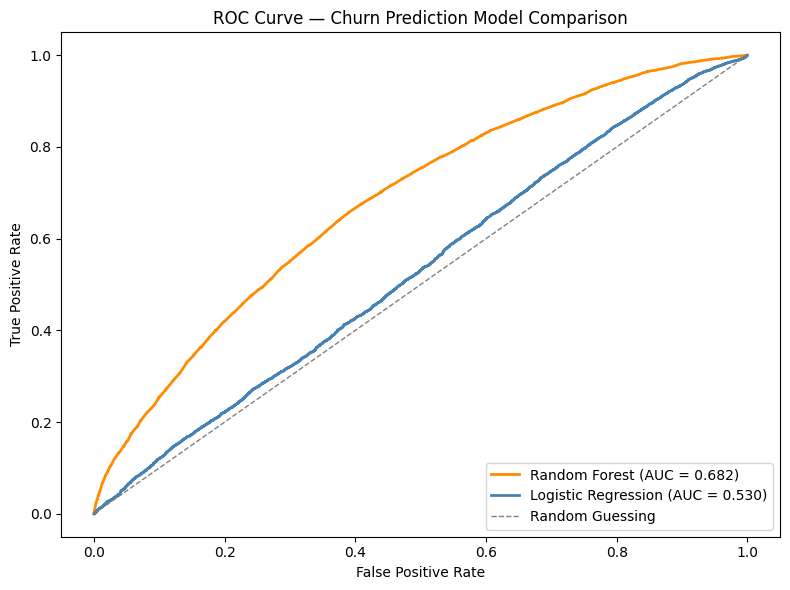

Saved to outputs/chart7_roc_curve.png


In [11]:
# Plotting the ROC curve — this is the visual version of the AUC score
# The further the curve bulges toward the top-left corner, the better the model

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2,
         label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(fpr_lr, tpr_lr, color='steelblue', lw=2,
         label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Guessing')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Churn Prediction Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()

plt.savefig(r'C:\Users\vedik\OneDrive\Desktop\Olist Churn Project\outputs\chart7_roc_curve.png', dpi=150)
plt.show()
print("Saved to outputs/chart7_roc_curve.png")

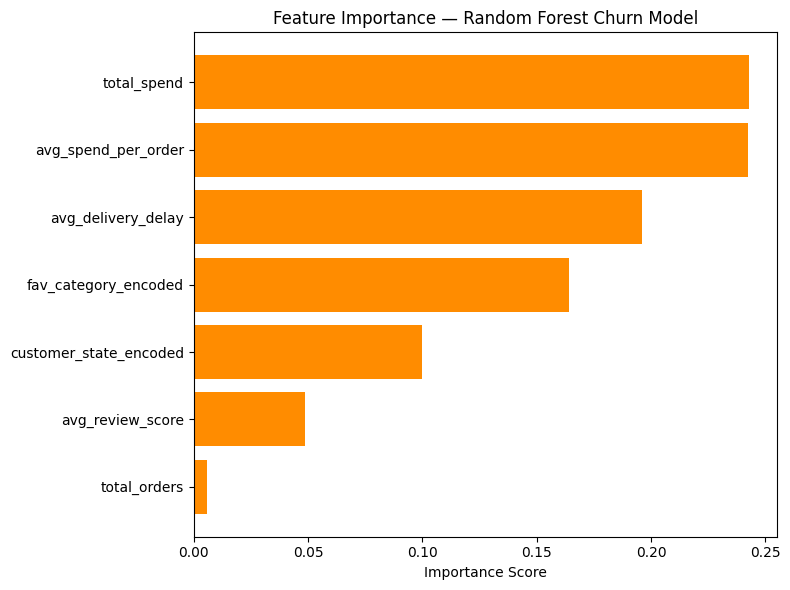

Saved to outputs/chart8_feature_importance.png

Feature importance values:
                  feature  importance
1             total_spend    0.243003
2     avg_spend_per_order    0.242550
4      avg_delivery_delay    0.195881
6    fav_category_encoded    0.164274
5  customer_state_encoded    0.099977
3        avg_review_score    0.048727
0            total_orders    0.005588


In [12]:
# Random Forest internally tracks how much each feature contributed to predictions
# Higher importance = that feature was more useful for splitting churners from loyals

feature_importance = pd.DataFrame({
    'feature': clean_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'],
         color='darkorange')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest Churn Model')
plt.tight_layout()

plt.savefig(r'C:\Users\vedik\OneDrive\Desktop\Olist Churn Project\outputs\chart8_feature_importance.png', dpi=150)
plt.show()
print("Saved to outputs/chart8_feature_importance.png")
print("\nFeature importance values:")
print(feature_importance.sort_values('importance', ascending=False))

**Spend dominates (48.5% combined) — The model uses spending behaviour as the primary signal. This makes sense because 96.9% of customers placed exactly one order, so spend level is essentially the only strong differentiator between customers.
Delivery delay is #3 at 19.6% — Confirms our Phase 3 finding. Logistics is the most actionable driver Olist can actually fix.
Review score is nearly irrelevant at 4.9% — Perfectly confirms chart1 from Phase 3. Satisfaction score is a weak churn signal.
total_orders at 0.6% — Almost zero importance because 96.9% of customers have exactly 1 order. There's no variation to learn from.**


In [13]:
# pickle saves the trained model to disk so it can be loaded and used later
# without retraining from scratch

import pickle

model_path = r'C:\Users\vedik\OneDrive\Desktop\Olist Churn Project\outputs\churn_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(rf_model, f)

print("Model saved successfully!")
print(f"Location: {model_path}")

# Verify it can be loaded back
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

print("\nModel reload verified!")
print("Model type:", type(loaded_model))

Model saved successfully!
Location: C:\Users\vedik\OneDrive\Desktop\Olist Churn Project\outputs\churn_model.pkl

Model reload verified!
Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [14]:
print("=" * 55)
print("PHASE 4 — CHURN PREDICTION MODEL — COMPLETE")
print("=" * 55)

print("""
MODELS TRAINED:
  - Logistic Regression (baseline)
  - Random Forest (final model)

MODEL PERFORMANCE (Random Forest):
  - Accuracy:  65%
  - AUC Score: 0.682
  - Churner Recall: 77% (catches 77% of all churners)

KEY LESSON LEARNED:
  - Data leakage detected and fixed (days_since_last_purchase)

TOP CHURN PREDICTORS:
  1. total_spend          (24.3%)
  2. avg_spend_per_order  (24.2%)
  3. avg_delivery_delay   (19.6%)
  4. fav_category         (16.4%)
  5. customer_state       (10.0%)
  6. avg_review_score      (4.9%)
  7. total_orders          (0.6%)

BUSINESS INSIGHT:
  Spend behaviour and delivery experience are the
  strongest predictors of churn. Review score is
  nearly irrelevant — confirming Phase 3 findings.

OUTPUTS SAVED:
  - outputs/chart7_roc_curve.png
  - outputs/chart8_feature_importance.png
  - outputs/churn_model.pkl
""")

print("=" * 55)
print("Next: Phase 5 — Power BI Dashboard")
print("=" * 55)

PHASE 4 — CHURN PREDICTION MODEL — COMPLETE

MODELS TRAINED:
  - Logistic Regression (baseline)
  - Random Forest (final model)

MODEL PERFORMANCE (Random Forest):
  - Accuracy:  65%
  - AUC Score: 0.682
  - Churner Recall: 77% (catches 77% of all churners)

KEY LESSON LEARNED:
  - Data leakage detected and fixed (days_since_last_purchase)

TOP CHURN PREDICTORS:
  1. total_spend          (24.3%)
  2. avg_spend_per_order  (24.2%)
  3. avg_delivery_delay   (19.6%)
  4. fav_category         (16.4%)
  5. customer_state       (10.0%)
  6. avg_review_score      (4.9%)
  7. total_orders          (0.6%)

BUSINESS INSIGHT:
  Spend behaviour and delivery experience are the
  strongest predictors of churn. Review score is
  nearly irrelevant — confirming Phase 3 findings.

OUTPUTS SAVED:
  - outputs/chart7_roc_curve.png
  - outputs/chart8_feature_importance.png
  - outputs/churn_model.pkl

Next: Phase 5 — Power BI Dashboard
